In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib 
import plotly.express as px
%matplotlib inline

In [2]:
filename = 'titanic.csv'
df = pd.read_csv(filename)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [4]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [5]:
df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [6]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [7]:
df['Ticket'].value_counts()

Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length: 681, dtype: int64

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
input_cols = list(df.columns)[2:]
input_cols.remove('Name')
target_col = ['Survived']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df[input_cols],df[target_col],random_state=42)

print(f"Training shape: {x_train.shape}")
print(f"Testing shape: {x_test.shape}")


Training shape: (668, 9)
Testing shape: (223, 9)


In [35]:
x_train = x_train.drop('Cabin', axis=1)
x_test = x_test.drop('Cabin', axis=1)

In [36]:
numerical_cols = x_train.select_dtypes(include=np.number).columns.to_list()
cat_cols = x_train.select_dtypes(include='object').columns.to_list()
cat_cols

['Sex', 'Ticket', 'Embarked']

In [37]:
from sklearn.impute import SimpleImputer

imputer  = SimpleImputer(strategy='mean').fit(df[numerical_cols])

x_train[numerical_cols] = imputer.transform(x_train[numerical_cols])
x_test[numerical_cols] = imputer.transform(x_test[numerical_cols])

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler().fit(df[numerical_cols])

x_train[numerical_cols] = scaler.transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

x_train[numerical_cols].describe()

,Pclass,Age,SibSp,Parch,Fare
count,668.000000,668.000000,668.000000,668.000000,6.680000e+02
mean,-0.583271,-0.005286,0.001082,0.001726,2.392933e-07
std,0.102963,0.000026,0.002315,0.003683,3.837392e-07
min,-0.750000,-0.005344,0.000000,0.000000,0.000000e+00
25%,-0.625000,-0.005301,0.000000,0.000000,5.893210e-08
50%,-0.500000,-0.005286,0.000000,0.000000,1.070817e-07
75%,-0.500000,-0.005275,0.001953,0.000000,2.268049e-07
max,-0.500000,-0.005186,0.015625,0.027778,3.809797e-06


In [ ]:
x_train[cat_cols] = x_train[cat_cols].fillna('Unknown')
x_test[cat_cols] = x_test[cat_cols].fillna('Unknown')

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
298,-0.750,male,-0.005286,0.000000,0.000000,19988,2.268049e-07,S
884,-0.500,male,-0.005295,0.000000,0.000000,SOTON/OQ 392076,5.242540e-08,S
247,-0.625,female,-0.005297,0.000000,0.009259,250649,1.078253e-07,S
478,-0.500,male,-0.005301,0.000000,0.000000,350060,5.592638e-08,S
305,-0.750,male,-0.005343,0.001953,0.009259,113781,1.126960e-06,S
...,...,...,...,...,...,...,...,...
106,-0.500,female,-0.005303,0.000000,0.000000,343120,5.688714e-08,S
270,-0.750,male,-0.005286,0.000000,0.000000,113798,2.305231e-07,S
860,-0.500,male,-0.005264,0.003906,0.000000,350026,1.049125e-07,S
435,-0.750,female,-0.005317,0.001953,0.009259,113760,8.923473e-07,S


In [41]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(x_train[cat_cols])

encoded_cols = list(encoder.get_feature_names_out(cat_cols))

In [42]:
x_train[encoded_cols] = encoder.transform(x_train[cat_cols])
x_test[encoded_cols] = encoder.transform(x_test[cat_cols])

C:\Users\KUSHANKUR\AppData\Local\Temp\ipykernel_9108\3495607600.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_train[encoded_cols] = encoder.transform(x_train[cat_cols])
C:\Users\KUSHANKUR\AppData\Local\Temp\ipykernel_9108\3495607600.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_train[encoded_cols] = encoder.transform(x_train[cat_cols])
C:\Users\KUSHANKUR\AppData\Local\Temp\ipykernel_9108\3495607600.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many

In [43]:
X_train = x_train[numerical_cols + encoded_cols]
X_test = x_test[numerical_cols + encoded_cols]

In [44]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
y_pred = model.predict(X_test)

In [51]:
print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.8116591928251121


[Text(0.5, 0.875, 'Sex_female <= 0.5\ngini = 0.471\nsamples = 668\nvalue = [415, 253]'),
 Text(0.25, 0.625, 'Age <= -0.005\ngini = 0.307\nsamples = 439\nvalue = [356, 83]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'SibSp <= 0.006\ngini = 0.408\nsamples = 21\nvalue = [6, 15]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Pclass <= -0.688\ngini = 0.272\nsamples = 418\nvalue = [350, 68]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Pclass <= -0.562\ngini = 0.383\nsamples = 229\nvalue = [59, 170]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Ticket_113781 <= 0.5\ngini = 0.064\nsamples = 120\nvalue = [4, 116]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Fare <= 0.0\ngini = 0.5\nsamples = 109\nvalue = [55, 54]'),
 Text(0.8125, 0.125, '\n  (...)  \n'),
 Text(0.9375, 0.125, '\n  (...)  \n')]

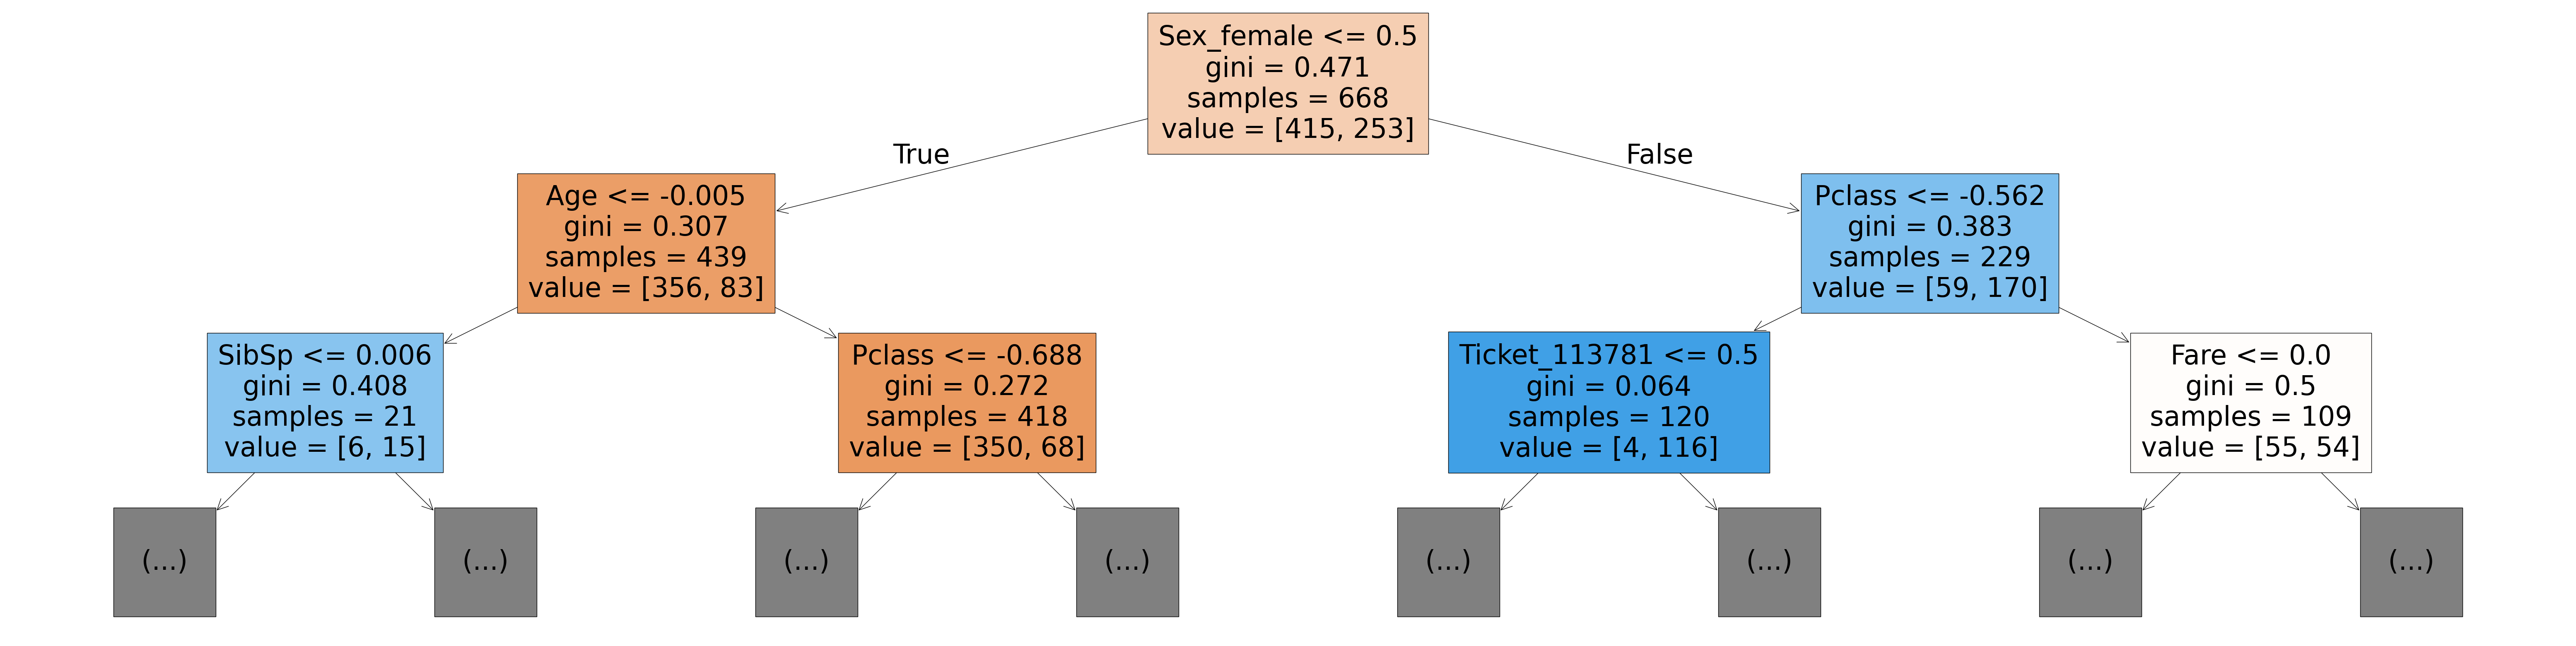

In [52]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True)

In [53]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)

,feature,importance
5,Sex_female,0.294052
0,Pclass,0.100501
1,Age,0.099023
4,Fare,0.075421
2,SibSp,0.030806
71,Ticket_1601,0.011664
268,Ticket_347077,0.011499
35,Ticket_113781,0.007877
322,Ticket_349909,0.007360
536,Embarked_C,0.006383


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

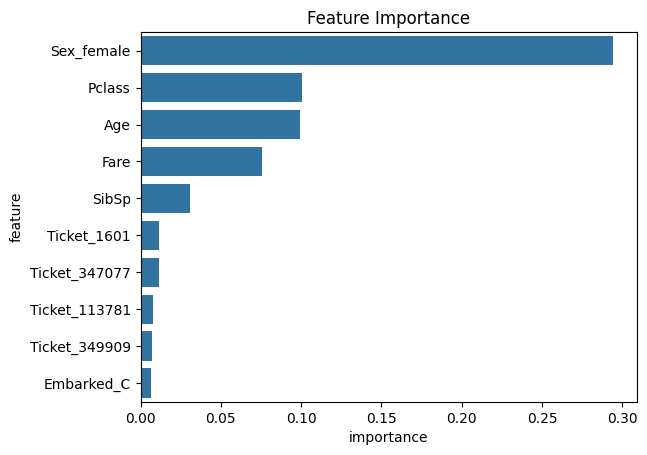

In [54]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')

In [55]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, y_train)
    train_acc = 1 - model.score(X_train, y_train)
    test_acc = 1 - model.score(X_test, y_test)
    return {'max depth': md, 'training error': train_acc, 'test error': test_acc}

In [56]:
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1,21)])
errors_df

,max depth,training error,test error
0,1,0.212575,0.215247
1,2,0.197605,0.224215
2,3,0.166168,0.197309
3,4,0.148204,0.183857
4,5,0.137725,0.188341
5,6,0.134731,0.188341
6,7,0.121257,0.188341
7,8,0.104790,0.183857
8,9,0.086826,0.188341
9,10,0.076347,0.192825


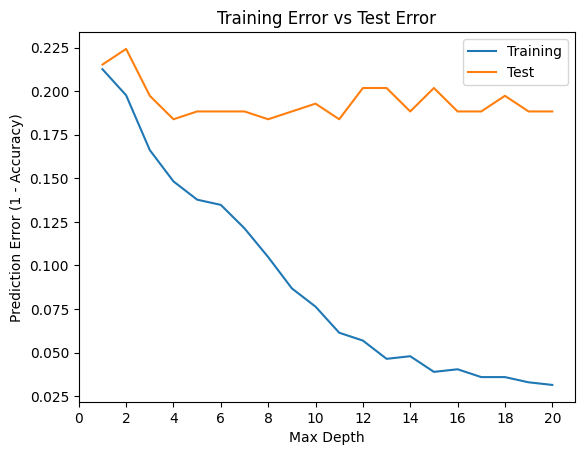

In [57]:
plt.figure()
plt.plot(errors_df['max depth'], errors_df['training error'])
plt.plot(errors_df['max depth'], errors_df['test error'])
plt.title('Training Error vs Test Error')
plt.xticks(range(0,21,2))
plt.xlabel('Max Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Test'])

In [59]:
# we get the best fit from above plot i.e. max depth = 4 gives minimum error
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
print(f"New Model accuracy: {model.score(X_test, y_test)*100:.4f}%")

New Model accuracy: 81.6143%
